In [254]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier


In [255]:
triangles = np.array([
    [0.55, 0.57],
    [0.53, 0.53],
    [0.49, 0.49],
    [0.43, 0.45],
    [0.60, 0.55],
    [0.55, 0.50],

])

dots = np.array([
    [0.52, 0.48],
    [0.50, 0.55],
    [0.60, 0.45],
    [0.48, 0.52],
])

query = np.array([[0.5, 0.5]])

X = np.vstack([triangles, dots])
y = np.array([0] * len(triangles) + [1] * len(dots))


In [256]:
k = 10                     # try: 1, 3, 5, 7, 11, ...
metric = "euclidean"       # try: "manhattan", "chebyshev", "minkowski", "cosine"
weights = "uniform"        # or "distance"

knn = KNeighborsClassifier(
    n_neighbors=k,
    metric=metric,
    weights=weights
)

knn.fit(X, y)
prediction = knn.predict(query)[0]


In [257]:
distances, indices = knn.kneighbors(query)
nn_idx = indices[0]
nn_dist = distances[0]


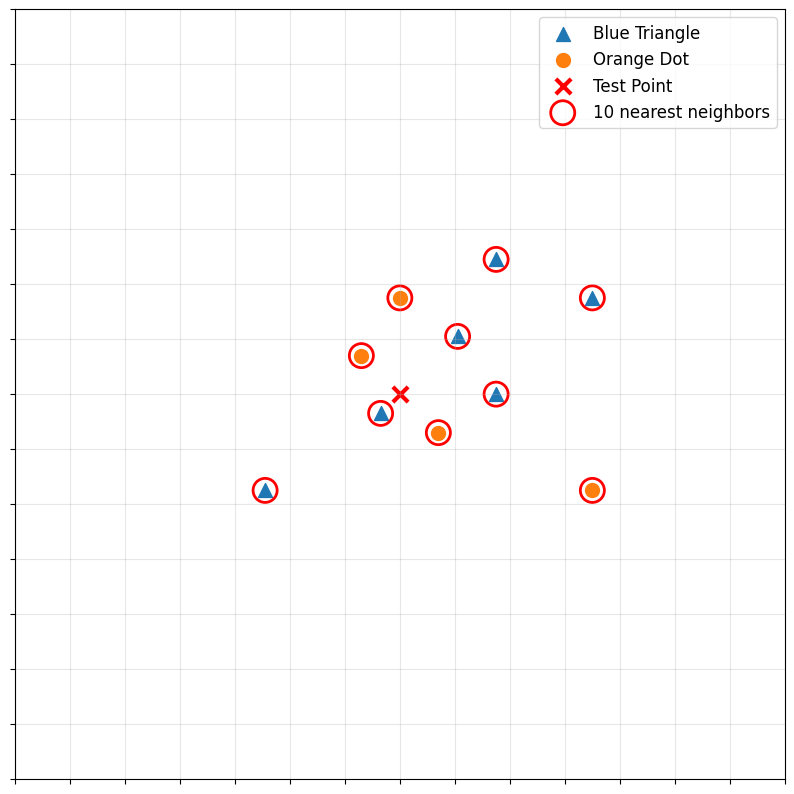

In [258]:
plt.figure(figsize=(10, 10))

plt.scatter(triangles[:, 0], triangles[:, 1],
            marker="^", s=100, label="Blue Triangle")
plt.scatter(dots[:, 0], dots[:, 1],
            marker="o", s=100, label="Orange Dot")

plt.scatter(query[0, 0], query[0, 1],
            marker="x", s=120, linewidths=3, label="Test Point", color="red")

plt.scatter(X[nn_idx, 0], X[nn_idx, 1],
            facecolors="none", edgecolors="red", s=300, linewidths=2,
            label=f"{k} nearest neighbors")

plt.gca().set_aspect("equal", adjustable="box")

plt.grid(True, alpha=0.7)

plt.legend(loc="upper right", fontsize=12)

ax = plt.gca()

ax.set_xticks(np.linspace(0.3, 0.7, 15))
ax.set_yticks(np.linspace(0.3, 0.7, 15))

ax.tick_params(labelbottom=False, labelleft=False)

ax.grid(True, alpha=0.3)

plt.show()


In [259]:
print(f"k = {k}")
print(f"metric = {metric}")
print(f"prediction = {prediction}")

print("\nNearest neighbors:")
for i, idx in enumerate(nn_idx):
    cls = y[idx]
    cls_name = "Blue Triangle" if cls == 0 else "Orange Dot"
    pt = X[idx]
    print(f"{i+1:2d}: point=({pt[0]:.2f}, {pt[1]:.2f}), "
          f"distance={nn_dist[i]:.4f}, class={cls_name}")


k = 10
metric = euclidean
prediction = 0

Nearest neighbors:
 1: point=(0.49, 0.49), distance=0.0141, class=Blue Triangle
 2: point=(0.52, 0.48), distance=0.0283, class=Orange Dot
 3: point=(0.48, 0.52), distance=0.0283, class=Orange Dot
 4: point=(0.53, 0.53), distance=0.0424, class=Blue Triangle
 5: point=(0.55, 0.50), distance=0.0500, class=Blue Triangle
 6: point=(0.50, 0.55), distance=0.0500, class=Orange Dot
 7: point=(0.55, 0.57), distance=0.0860, class=Blue Triangle
 8: point=(0.43, 0.45), distance=0.0860, class=Blue Triangle
 9: point=(0.60, 0.45), distance=0.1118, class=Orange Dot
10: point=(0.60, 0.55), distance=0.1118, class=Blue Triangle
